# Sales Data Analysis
**CloudExify Data Science Internship — Month 1, Project 1**

This notebook loads a sales dataset, cleans it, explores it statistically, visualizes trends, and produces a summary report — following the steps in the project guide.

## Step 1 — Import Libraries and Load Data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load CSV file
df = pd.read_csv('sales_data.csv')

# Explore data
print(df.head())        # First 5 rows
print(df.shape)         # Rows, columns
print(df.info())        # Data types, nulls
print(df.describe())    # Statistics


         Date       Product     Category   Region  Units    Amount
0  2025-12-08  Notebook Set   Stationery    South      8    4544.0
1  2025-11-04    Study Desk    Furniture     West      1   17188.0
2  2025-03-07     Air Fryer   Appliances  Central      4   52296.0
3  2025-09-06        Laptop  Electronics    North      3  266127.0
4  2025-08-16  Notebook Set   Stationery     West      4    3560.0
(3015, 6)
<class 'pandas.DataFrame'>
RangeIndex: 3015 entries, 0 to 3014
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Date      3015 non-null   str    
 1   Product   3015 non-null   str    
 2   Category  3015 non-null   str    
 3   Region    2990 non-null   str    
 4   Units     3015 non-null   int64  
 5   Amount    3015 non-null   float64
dtypes: float64(1), int64(1), str(4)
memory usage: 141.5 KB
None
             Units         Amount
count  3015.000000    3015.000000
mean      3.051078   51532.498507
std       1.80

## Step 2 — Data Cleaning

In [3]:
# Check for missing values
print(df.isnull().sum())

# Drop rows with missing values
df = df.dropna()

# Remove duplicates
df = df.drop_duplicates()

# Convert date column to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Check data types
print(df.dtypes)


Date         0
Product      0
Category     0
Region      25
Units        0
Amount       0
dtype: int64
Date        datetime64[us]
Product                str
Category               str
Region                 str
Units                int64
Amount             float64
dtype: object


## Step 3 — Exploratory Analysis

In [4]:
# Basic statistics
print("Total Revenue: Rs", df['Amount'].sum())
print("Avg Sale: Rs", df['Amount'].mean())
print("Median Sale: Rs", df['Amount'].median())
print("Std Dev: Rs", df['Amount'].std())

# Value counts
print(df['Product'].value_counts())

# Grouping
by_product = df.groupby('Product')['Amount'].sum().sort_values(ascending=False)
print(by_product.head(10))


Total Revenue: Rs 153430523.0
Avg Sale: Rs 51573.2850420168
Median Sale: Rs 20502.0
Std Dev: Rs 90770.91864802598
Product
Laptop           234
Running Shoes    234
Backpack         231
Notebook Set     224
Air Fryer        222
Microwave        221
Blender          221
Office Chair     211
Bookshelf        209
Study Desk       199
Smartphone       198
Headphones       193
Jacket           191
T-Shirt          187
Name: count, dtype: int64
Product
Laptop           62189375.0
Smartphone       31211267.0
Study Desk       10782415.0
Microwave         9848811.0
Office Chair      7763304.0
Air Fryer         7037392.0
Bookshelf         5388707.0
Blender           5207729.0
Running Shoes     4024647.0
Jacket            3810903.0
Name: Amount, dtype: float64


## Step 4 — Visualization

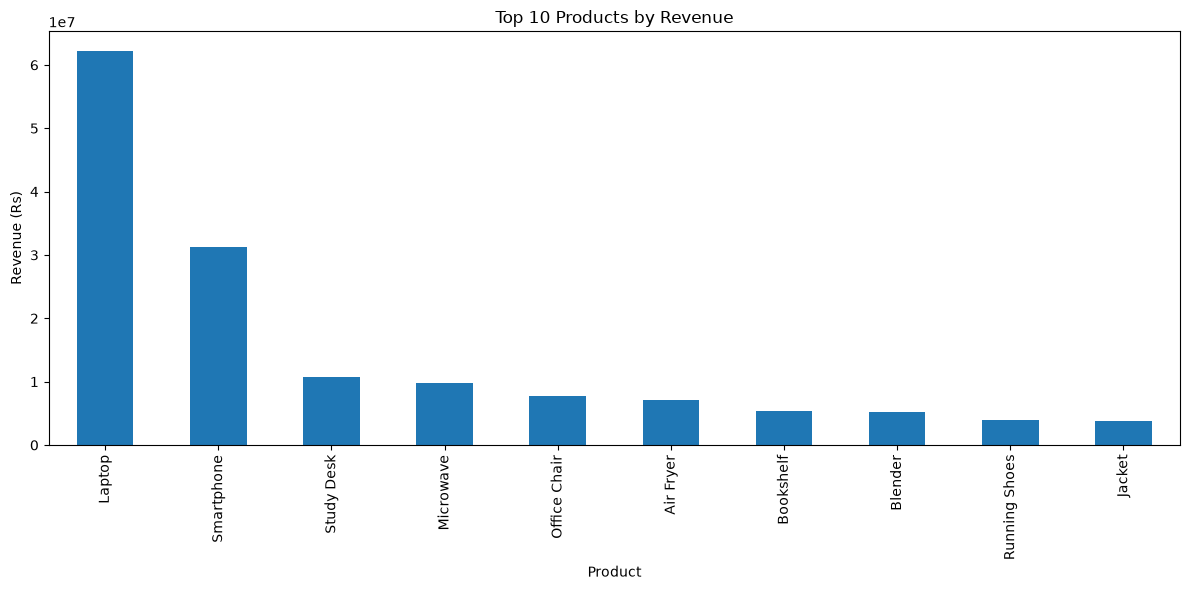

In [5]:
# Bar chart - Top 10 products
top_products = df.groupby('Product')['Amount'].sum().nlargest(10)
top_products.plot(kind='bar', figsize=(12, 6))
plt.title('Top 10 Products by Revenue')
plt.xlabel('Product')
plt.ylabel('Revenue (Rs)')
plt.tight_layout()
plt.show()


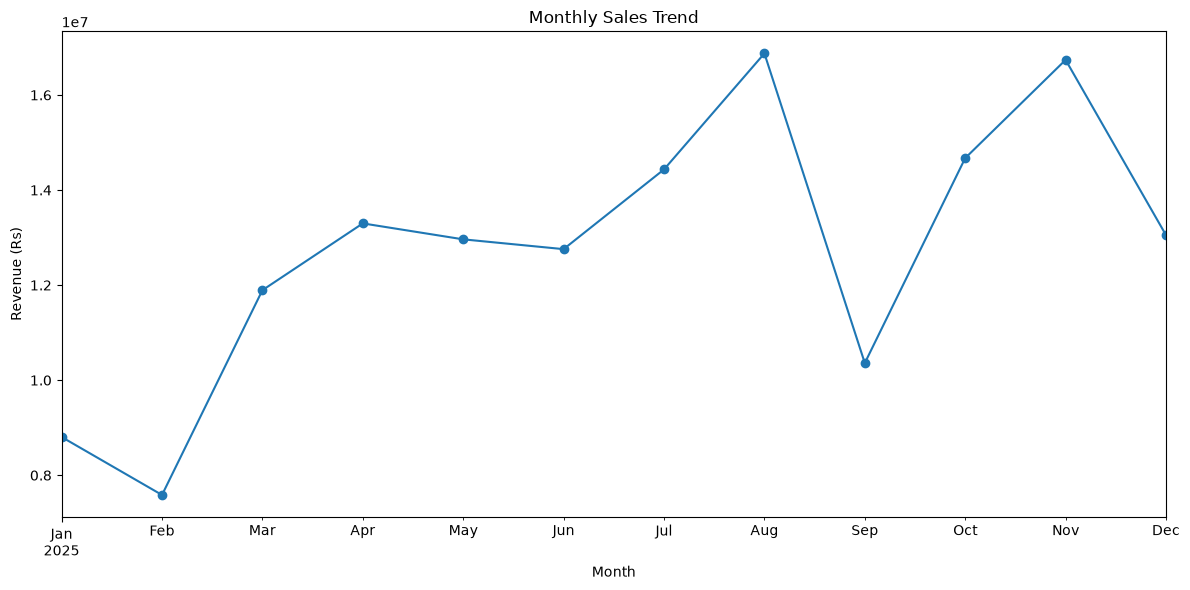

In [6]:
# Line plot - Monthly sales trend
monthly_sales = df.groupby(df['Date'].dt.to_period('M'))['Amount'].sum()
monthly_sales.plot(kind='line', figsize=(12, 6), marker='o')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Revenue (Rs)')
plt.tight_layout()
plt.show()


## Step 5 — Analysis by Category

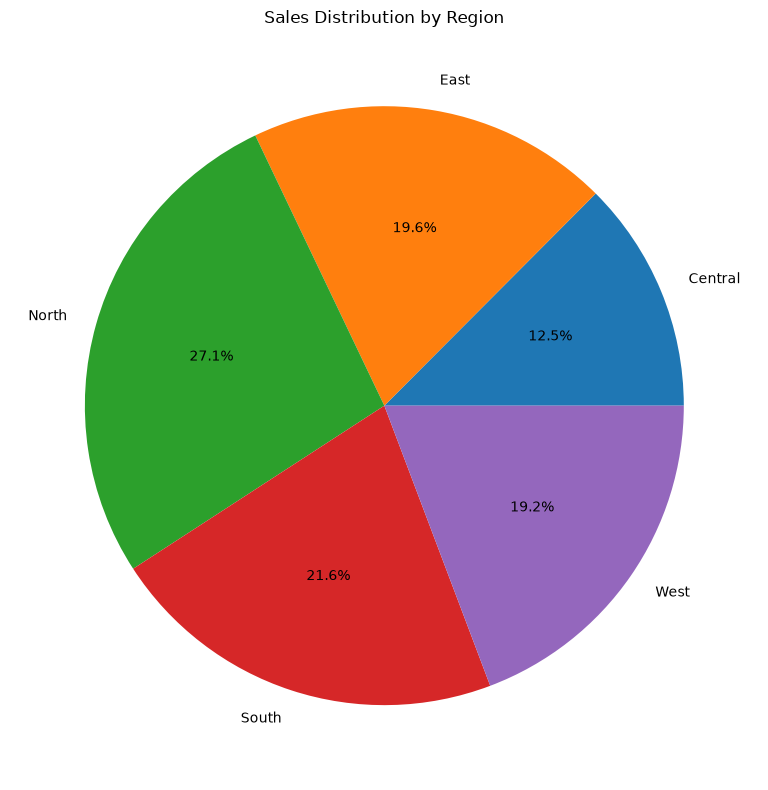

In [7]:
# Sales by region
by_region = df.groupby('Region')['Amount'].sum()
by_region.plot(kind='pie', autopct='%1.1f%%', figsize=(8, 8))
plt.title('Sales Distribution by Region')
plt.ylabel('')
plt.tight_layout()
plt.show()


In [8]:
# Category comparison
by_category = df.groupby('Category').agg({
    'Amount': 'sum',
    'Units': 'sum'
})
print(by_category)


                 Amount  Units
Category                      
Apparel       8499901.0   1863
Appliances   22093932.0   2040
Electronics  96334308.0   1918
Furniture    23934426.0   1869
Stationery    2567956.0   1378


## Step 6 — Summary Report

In [9]:
# Summary report
report_lines = []
report_lines.append("="*50)
report_lines.append("SALES ANALYSIS REPORT")
report_lines.append("="*50)
report_lines.append(f"Total Records: {len(df)}")
report_lines.append(f"Date Range: {df['Date'].min().date()} to {df['Date'].max().date()}")
report_lines.append(f"Total Revenue: Rs {df['Amount'].sum():,.0f}")
report_lines.append(f"Average Sale: Rs {df['Amount'].mean():,.0f}")
report_lines.append(f"Median Sale: Rs {df['Amount'].median():,.0f}")
report_lines.append("")
report_lines.append("Top 5 Products:")
report_lines.append(str(df.groupby('Product')['Amount'].sum().nlargest(5)))
report_lines.append("")
best_month = df.groupby(df['Date'].dt.to_period('M'))['Amount'].sum().idxmax()
report_lines.append(f"Best Month: {best_month}")

report_text = "\n".join(report_lines)
print(report_text)

# Save to file for submission
with open('report.txt', 'w') as f:
    f.write(report_text)


SALES ANALYSIS REPORT
Total Records: 2975
Date Range: 2025-01-01 to 2025-12-31
Total Revenue: Rs 153,430,523
Average Sale: Rs 51,573
Median Sale: Rs 20,502

Top 5 Products:
Product
Laptop          62189375.0
Smartphone      31211267.0
Study Desk      10782415.0
Microwave        9848811.0
Office Chair     7763304.0
Name: Amount, dtype: float64

Best Month: 2025-08
